# About this notebook
This notebook contains code to obtain the topics for assistance requests (AR).  It must be run before using the SoW_topics notebook as the resulting csv is merged with the SoW topics.  The input is a locally saved version of the FEMA mission assignments dataset downloaded from the OpenFEMA portal found at: https://www.fema.gov/openfema-data-page/mission-assignments-v2.  The output is the AR_topics and AR_topics_cluster_centers csv files.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Upload data, exploratory analysis of mission assignments.

In [2]:
df = pd.read_csv('MissionAssignments.csv')

In [3]:
MA_df=df[(df['declarationType']!='SU')&(df['maAmendNumber']==0)&(df['supportFunction']<=15)]

In [4]:
ESF=MA_df['supportFunction'].to_list()

In [5]:
values, counts = np.unique(ESF,return_counts=True)

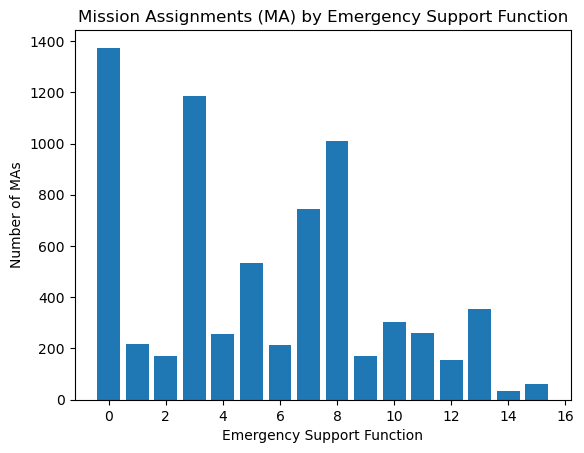

In [6]:
plt.bar(values, counts)
plt.title('Mission Assignments (MA) by Emergency Support Function')
plt.ylabel('Number of MAs')
plt.xlabel('Emergency Support Function')
plt.show()

In [7]:
types=MA_df['incidentType'].to_list()

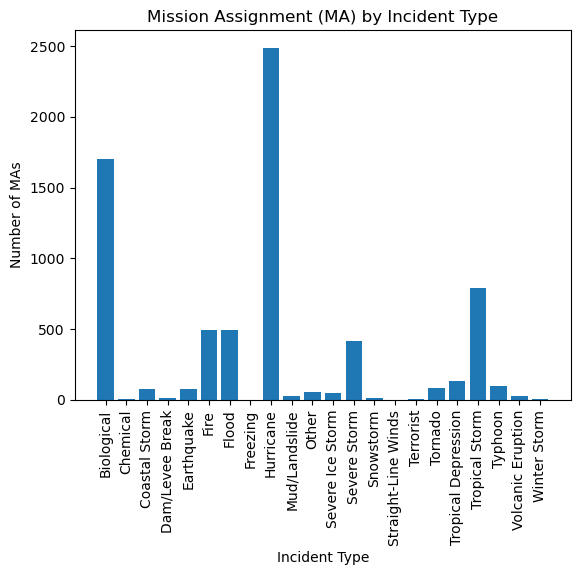

In [8]:
values, counts = np.unique(types, return_counts=True)
plt.bar(values, counts)
plt.tick_params('x',labelrotation=90.0)
plt.title('Mission Assignment (MA) by Incident Type')
plt.ylabel('Number of MAs')
plt.xlabel('Incident Type')
plt.show()

# Use top2vec to get topics for AR statements

In [7]:
from top2vec import Top2Vec
from nltk.tokenize import word_tokenize

In [10]:
AR_list = MA_df['assistanceRequested'].to_list()

In [11]:
#model=Top2Vec(AR_list)
model = Top2Vec.load('basic_topics_model')

In [42]:
#model.save('basic_topics_model')

In [12]:
topic_sizes, topic_nums = model.get_topic_sizes()

In [13]:
topic_list=topic_nums.tolist()
size_list=topic_sizes.tolist()

In [14]:
topic_words, word_scores, topic_nums = model.get_topics()

In [153]:
documents, document_scores, document_ids = model.search_documents_by_topic(topic_num=109, num_docs=10)

In [17]:
#Get document most similar to each topic
doc_dict={}
for t in topic_list:
    documents, document_scores, document_ids = model.search_documents_by_topic(topic_num=t, num_docs=1)
    doc_dict[t]=documents[0]

In [19]:
ar_docs=pd.DataFrame(list(doc_dict.values()),index=list(doc_dict.keys()))

In [21]:
ar_docs.to_csv('AR_topics_cluster_centers.csv')

In [20]:
#get topic number for each document and assign to dictionary to create dataframe
topic_dict={}
for t in topic_list:
    documents, document_scores, document_ids = model.search_documents_by_topic(topic_num=t, num_docs=size_list[t])
    doc_list=document_ids.tolist()
    for doc in doc_list:
        topic_dict[doc]=t

In [97]:
key_list=list(topic_dict.keys())
key_list.sort()

sort_topic = {i: topic_dict[i] for i in key_list}
#sort_topic

In [103]:
value_list = list(sort_topic.values())
value_list[0:10]

[28, 23, 23, 30, 32, 99, 23, 4, 108, 108]

In [77]:
topic_series = pd.Series(sort_topic)
topic_series.head(10)

0     28
1     23
2     23
3     30
4     32
5     99
6     23
7      4
8    108
9    108
dtype: int64

In [115]:
#add topic numbers to the original mission assignment dataframe as a series
MA_df['AR_topic']=value_list

C:\Users\sbpow\AppData\Local\Temp\ipykernel_24336\3230160391.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MA_df['AR_topic']=value_list


In [119]:
MA_df.head(10)

,incidentId,incidentName,incidentType,disasterNumber,declarationType,declarationTitle,maId,maAmendNumber,actionId,maType,...,maFedCostSharePct,maSttCostShareAmount,maFedCostShareAmount,maPriority,assistanceRequested,statementOfWork,id,hash,lastRefresh,AR_topic
0,2024081901,R1_Severe Storm-Flooding_08182024,Severe Storm,3612.0,EM,"SEVERE STORMS, FLOODING, LANDSLIDES, AND MUDSL...",3612EMCTDOI-USGS01,0,476360,FOS,...,1.0,0.0,20000.0,High,USGS Field measurements of flood-water heights...,"As directed by and in coordination with FEMA, ...",ecbcf24e-7d9e-4ced-ae57-4871181703e1,497d57a5e4d071da1721548476b50b64a7321bdd,2024-08-27T18:24:53.439Z,28
49,2024072801,Tropical Storm Debby,Tropical Storm,4806.0,DR,HURRICANE DEBBY,4806DRFLVA02,0,475497,FOS,...,1.0,0.0,7500.0,Normal,Activate VHA OEM to NRCC ESF-8 PHMS. This is a...,As directed by and in coordination with FEMA a...,22650dc6-6edd-4320-a94b-0806a23a6a8f,1122d0c70dbda983148af72f79f88cf22d58ccc2,2024-08-27T18:24:53.439Z,23
50,2024072801,Tropical Storm Debby,Tropical Storm,4806.0,DR,HURRICANE DEBBY,4806DRFLVA01,0,475447,FOS,...,1.0,0.0,3000.0,Normal,Activate VA to NRCC. This is a re-issuance of ...,"As directed by and in coordination with FEMA, ...",fa616458-5823-4f1a-a267-36c0dec9f0c0,3169ee76944697a6c8622ba9680c0da3dfd5d8a0,2024-08-27T18:24:53.439Z,23
51,2024072801,Tropical Storm Debby,Tropical Storm,4806.0,DR,HURRICANE DEBBY,4806DRFLUSDA-FS01,0,475492,FOS,...,1.0,0.0,7000.0,Normal,Activate USFS to the NRCC. This is a re-issuan...,"As directed by and in coordination with FEMA, ...",efa7a3d9-8b32-4cd6-8f68-fca08608c4cd,975a2eb34e0a5303e696921181676dda4a5a8480,2024-08-27T18:24:53.439Z,30
52,2024072801,Tropical Storm Debby,Tropical Storm,4806.0,DR,HURRICANE DEBBY,4806DRFLUSDA-APH01,0,475468,FOS,...,1.0,0.0,3000.0,Normal,"USDA liaison(s) to the NRCC, FEMA teams, or ot...","As directed by and in coordination with FEMA, ...",92fa3d06-c07c-43f9-8d87-8f59cb12bf78,d848273ccdcbd63796ae9d0d1616c0ee94b73938,2024-08-27T18:24:53.439Z,32
53,2024072801,Tropical Storm Debby,Tropical Storm,4806.0,DR,HURRICANE DEBBY,4806DRFLHUD01,0,475467,FOS,...,1.0,0.0,3000.0,Normal,Activate HUD to NRCC or other teams and facili...,As directed by and in coordination with FEMA H...,4deef6f1-df5f-44f4-89b7-8710b69dba44,27942c1e8c6f0f7f8bd38610f2cfb2624b090e14,2024-08-27T18:24:53.439Z,99
54,2024072801,Tropical Storm Debby,Tropical Storm,4806.0,DR,HURRICANE DEBBY,4806DRFLHHS-ASPR02,0,475465,FOS,...,1.0,0.0,3000.0,Normal,Activate HHS to NRCC. This is a re-issuance of...,"As directed by and in coordination with FEMA, ...",f93f2146-a814-4a6d-92b2-c47f36ef3c2c,07ecb8b8038804d960a1ffad7b1c28a5acbe5419,2024-08-27T18:24:53.439Z,23
55,2024072801,Tropical Storm Debby,Tropical Storm,4806.0,DR,HURRICANE DEBBY,4806DRFLHHS-ASPR01,0,475280,FOS,...,1.0,0.0,159168.0,Life Sustaining,Activate Health and Human Services (HHS) for s...,"As directed by and in coordination with FEMA, ...",6f6298bd-1ba2-4be2-9b4c-6ecf712b1d3a,9c13b412b46aa5f8b5e541069334ed904ca7f1fd,2024-08-27T18:24:53.439Z,4
56,2024072801,Tropical Storm Debby,Tropical Storm,4806.0,DR,HURRICANE DEBBY,4806DRFLGSA02,0,475464,FOS,...,1.0,0.0,3000.0,High,"Activate GSA to NRCC, or other teams and facil...","As directed by and in coordination with FEMA, ...",6260595a-c8aa-4b14-933a-3842d3c18851,1064cb8391fac03fbf1ea46416ddc9bdd5b95201,2024-08-27T18:24:53.439Z,108
57,2024072801,Tropical Storm Debby,Tropical Storm,4806.0,DR,HURRICANE DEBBY,4806DRFLGSA01,0,475244,FOS,...,1.0,0.0,15000.0,High,"Activate GSA to RRCC, IOF, JFO, or other teams...","As directed by and in coordination with FEMA, ...",a12fea39-cdf0-429f-91a2-b2d247eafbd6,662fbae0f4a613257220a51c8c75d48e1aac4702,2024-08-27T18:24:53.439Z,108


In [121]:
topic_df=MA_df[['maId','assistanceRequested','AR_topic']]

In [125]:
topic_df.to_csv('AR_topics.csv')